# Linear Regression from Scratch

Predicting house prices on the [Housing Prices dataset](https://www.kaggle.com/datasets/yasserh/housing-prices-dataset) using a linear regression model implemented from scratch with NumPy (no scikit-learn).

**Pipeline:** one-hot encoding ->  train/test split -> feature scaling (z-score) -> batch gradient descent -> evaluation (R², cost).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## 1. Data Preparation

In [3]:
# One-hot encode the categorical columns

encoded_df = pd.get_dummies(df, columns=["airconditioning", "mainroad",
                                          "guestroom", "basement",
                                          "hotwaterheating", "prefarea",
                                          "furnishingstatus"],
                             drop_first=True)

encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   airconditioning_yes              545 non-null    bool 
 7   mainroad_yes                     545 non-null    bool 
 8   guestroom_yes                    545 non-null    bool 
 9   basement_yes                     545 non-null    bool 
 10  hotwaterheating_yes              545 non-null    bool 
 11  prefarea_yes                     545 non-null    bool 
 12  furnishingstatus_semi-furnished  545 non-null    b

In [4]:
# Split features from the target
X = encoded_df.drop(columns=["price"])
y = encoded_df["price"]

print(X.shape)
print(y.shape)

(545, 13)
(545,)


In [5]:
def train_test_split(X, y, test_size=0.2, seed=42):
    """ Shuffle and split into train / test sets."""
    np.random.seed(seed)

    rdm_indexes = np.random.permutation(len(X))
    train = int((1 - test_size) * len(X))

    index_train = rdm_indexes[:train]
    index_test = rdm_indexes[train:]

    X_train = X.iloc[index_train]
    y_train = y.iloc[index_train]
    X_test = X.iloc[index_test]
    y_test = y.iloc[index_test]

    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = train_test_split(X, y)

## 2. Feature Scaling


In [6]:
def scale_z_score_fit(X_train, cols):
    """Compute per column mean and std from the training set."""
    stats = {col: (df[col].mean(), df[col].std()) for col in cols}
    return stats


def scale_z_score_apply(df, cols, stats):
    """Apply previously computed mean std stats to a dataframe."""
    df = df.copy()
    for col in cols:
        mean, std = stats[col]
        df[col] = (df[col] - mean) / std
    return df


scale_cols = ["area", "bedrooms", "bathrooms", "stories", "parking"]

# Retrieve the mean & std
train_stats = scale_z_score_fit(X_train, scale_cols)

# Apply the train stats to both train and test
X_train = scale_z_score_apply(X_train, scale_cols, train_stats)
X_test = scale_z_score_apply(X_test, scale_cols, train_stats)

# Scaling the target the same way
y_mean, y_std = y_train.mean(), y_train.std()
y_train = (y_train - y_mean) / y_std
y_test = (y_test - y_mean) / y_std

X_train.head()

,area,bedrooms,bathrooms,stories,parking,airconditioning_yes,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
316,0.345350,1.402131,1.420507,0.224204,0.355649,False,False,False,True,False,False,False,True
77,0.621830,0.047235,1.420507,1.376952,-0.805002,True,True,False,False,False,True,False,False
360,-0.511737,-1.307661,-0.569663,-0.928544,-0.805002,False,True,False,False,False,False,True,False
90,-0.069369,0.047235,-0.569663,0.224204,-0.805002,True,True,False,False,False,False,True,False
493,-0.548601,0.047235,-0.569663,-0.928544,-0.805002,False,True,False,False,False,False,False,False


## 3. Model: Batch Gradient Descent

In [7]:
# Initialize weights and bias 

n_features = X_train.shape[1]
w = np.random.randn(n_features)
b = 0.0

print(w.shape)

(13,)


In [8]:
def compute_cost_function(X, y, w, b):
    """Compute the MSE cost function."""
    m = X.shape[0]
    y_pred = X @ w + b
    cost = (1 / (2 * m)) * np.sum((y - y_pred) ** 2)
    return cost


compute_cost_function(X_train, y_train, w, b)

2.792989890282789

In [9]:
def gradient_descent(X, y, w, b, learning_rate=0.01, iter=5000):
    """Run gradient descent and return the learned w, b and the cost history."""
    m = X.shape[0]
    cost_history = []

    for _ in range(iter):
        y_pred = X @ w + b
        dj_dw = (1 / m) * np.transpose(X) @ (y_pred - y)
        dj_db = (1 / m) * np.sum((y_pred - y))

        w, b = w - learning_rate * dj_dw, b - learning_rate * dj_db

        cost_history.append(compute_cost_function(X, y, w, b))

    return w, b, cost_history


w, b, cost_history = gradient_descent(X_train, y_train, w, b)

## 4. Check Convergence

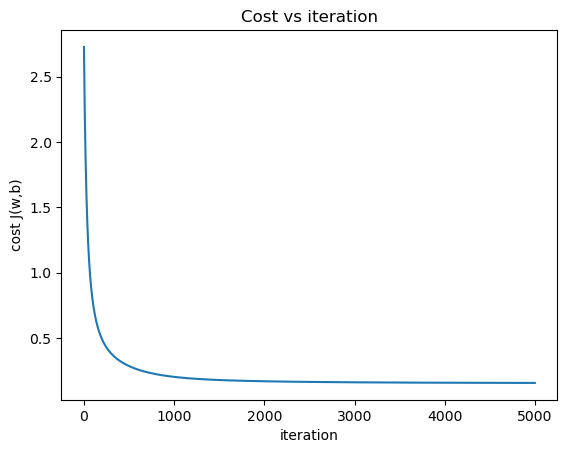

In [10]:
plt.plot(cost_history)
plt.xlabel("iteration")
plt.ylabel("cost J(w,b)")
plt.title("Cost vs iteration")
plt.show()

## 5. Evaluate on the test set

In [11]:
def r2_score(y_true, y_pred):
    """Compute the coefficient of determination."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot


test_cost = compute_cost_function(X_test, y_test, w, b)
y_test_pred = X_test @ w + b
test_r2 = r2_score(y_test, y_test_pred)

print(f"Test cost J: {test_cost:.4f}")
print(f"Test R^2:    {test_r2:.4f}")

Test cost J: 0.1784
Test R^2:    0.6452


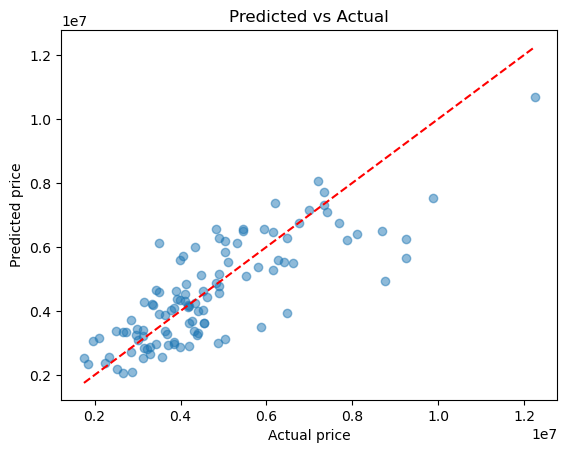

In [12]:
y_test_actual = y_test * y_std + y_mean
y_test_pred_actual = y_test_pred * y_std + y_mean

plt.scatter(y_test_actual, y_test_pred_actual, alpha=0.5)
plt.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()], "r--")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Predicted vs Actual")
plt.show()